# ExoFarm Transmission Spectra

Notebook de presentación para comparar los escenarios agrícolas A0-A3 en TRAPPIST-1e. El flujo está organizado en cuatro pasos: configurar escenarios, construir atmósferas, calcular espectros de transmisión y terminar generando observaciones sintéticas JWST para NIRSpec Prism + MIRI LRS.

La idea es que este notebook cuente la historia científica sin cargar retrievals, manteniendo las contribuciones moleculares como una sección diagnóstica compacta.

## 1. Configuración

Los escenarios, colores y conteos de observación viven en `exofarm_transmission_workflow.py`. Aquí sólo escogemos qué se muestra y si la última celda debe generar nuevamente los sintéticos.

In [1]:
import importlib

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from POSEIDON.utility import plot_collection
from POSEIDON.visuals import plot_spectra

# Jupyter keeps imported modules in memory.  Reload the helper so edits made in
# exofarm_transmission_workflow.py are visible without restarting the kernel.
import exofarm_transmission_workflow as exofarm_workflow
importlib.reload(exofarm_workflow)

from exofarm_transmission_workflow import (
    DEFAULT_PEAK_WINDOWS,
    OBSERVATION_TRANSIT_COUNTS,
    SCENARIOS,
    SYNTHETIC_DATA_DIR,
    compute_forward_spectra,
    compute_spectral_contributions,
    create_pressure_grid,
    create_trappist_system,
    define_forward_models,
    generate_synthetic_grid,
    load_profiles,
    make_atmospheres,
    make_wavelength_grid_and_opacities,
    plot_observations_by_noise_level,
    plot_observations_by_scenario,
    plot_peak_growth_relative_to_baseline,
    plot_spectral_contribution_baseline_grid,
    plot_spectral_contribution_comparison,
    plot_spectral_contributions_by_scenario,
    prepare_pandexo_base_data,
)

# Keep the presentation order explicit.  The helper contains the metadata, but
# the notebook decides which scenarios appear in the figures.
SCENARIO_KEYS = ["A0", "A1", "A2", "A3"]

# The synthetic grid is 5+5, 10+10, and 20+20 observations.  The default count
# is useful for later plot cells if we want to show one representative case.
DEFAULT_TRANSIT_COUNT = 20

# Set this to False when revisiting only the forward-spectrum figures.  The
# final synthetic-generation cell is intentionally the only cell with file writes.
RUN_SYNTHETIC_GENERATION = True
GAUSS_SCATTER = True

scenario_labels = [SCENARIOS[key]["name"] for key in SCENARIO_KEYS]
scenario_colours = [SCENARIOS[key]["colour"] for key in SCENARIO_KEYS]

print("Escenarios:", ", ".join(SCENARIO_KEYS))
print("Observaciones por instrumento:", OBSERVATION_TRANSIT_COUNTS)
print("Salida sintética:", SYNTHETIC_DATA_DIR)

/home/dasan/anaconda3/envs/POSEIDON/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Escenarios: A0, A1, A2, A3
Observaciones por instrumento: [5, 10, 20]
Salida sintética: /mnt/c/Proyectos/Astro/ExoFarm_MDwarfs/Transmission_Spectroscopy/notebooks/POSEIDON_output/TRAPPIST-1e/synthetic_data/base_1transit


## 2. Sistema, modelos y perfiles

Esta sección toma los perfiles `PT` y `chem` de `Transmission_Spectroscopy/profiles/`, define un modelo POSEIDON por escenario y construye las atmósferas correspondientes.

In [2]:
# Create the physical system and a common vertical grid.  All scenarios use the
# same pressure grid so differences in the spectra come from the PT/chemistry
# profiles, not from numerical discretization choices.
star, planet = create_trappist_system()
P, P_surf, P_ref, R_p_ref = create_pressure_grid()

# Each scenario has its own POSEIDON model object because the model name is used
# downstream in labels and output products.
models = define_forward_models(SCENARIO_KEYS)

# The profile readers interpolate the exported photochemical profiles onto P.
temperatures, compositions = load_profiles(models, P, SCENARIO_KEYS)

# Atmosphere dictionaries are the direct inputs to compute_spectrum(...).
atmospheres = make_atmospheres(
    planet,
    models,
    P,
    P_ref,
    R_p_ref,
    P_surf,
    temperatures,
    compositions,
)

print(f"Sistema listo: {planet['planet_name']}")
print(f"Capas atmosféricas: {len(P)}")
for key in SCENARIO_KEYS:
    print(f" - {key}: {SCENARIOS[key]['label']}")

Sistema listo: TRAPPIST-1e
Capas atmosféricas: 100
 - A0: Trappist_A0_PreAgri
 - A1: Trappist_A1_Current
 - A2: Trappist_A2_Moderate
 - A3: Trappist_A3_Extreme


## 3. Opacidades y espectros forward

Se usa una sola grilla de longitudes de onda, de 0.5 a 14 micras, para cubrir NIRSpec Prism y MIRI LRS. Todos los escenarios comparten la misma lista de especies, así que basta leer opacidades una vez con el modelo A0 como referencia.

In [3]:
# The wavelength grid spans both instruments in one model calculation:
# NIRSpec Prism is covered at short wavelengths and MIRI LRS at longer ones.
# Opacities are read once because all scenarios use the same molecular set.
wl, opac = make_wavelength_grid_and_opacities(models["A0"])

# Native spectra are kept at high resolution.  Plotting and synthetic data use
# later binning, which is safer than computing the physical spectrum directly on
# a coarse instrument-like grid.
spectra = compute_forward_spectra(planet, star, models, atmospheres, opac, wl)

print(f"Grilla espectral: {wl[0]:.2f}-{wl[-1]:.2f} micron")
for key in SCENARIO_KEYS:
    print(f" - spectrum_{key}: {spectra[key].shape}")

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
O2-O2 done
O2-CO2 done
O2-N2 done
H2O done
CO2 done
CH4 done
O2 done
O3 done
N2O done
NH3 done
Opacity pre-interpolation complete.
Grilla espectral: 0.50-14.00 micron
 - spectrum_A0: (33322,)
 - spectrum_A1: (33322,)
 - spectrum_A2: (33322,)
 - spectrum_A3: (33322,)


## 4. Figura principal: A0-A3

Primero se muestran los espectros de transmisión sin ruido observacional. Esta es la figura base para ver la progresión A0 → A1 → A2 → A3.

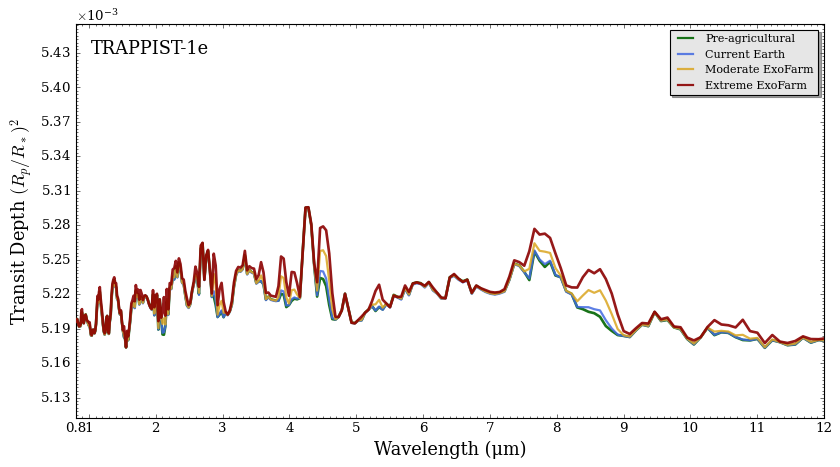

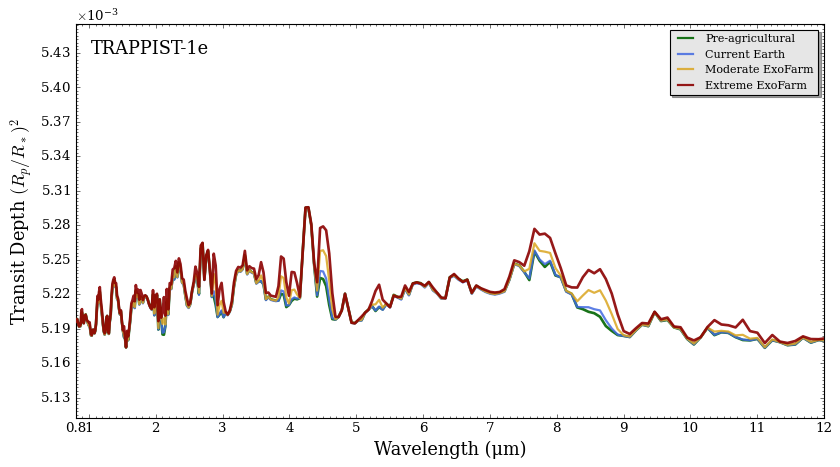

In [4]:
# Choose plot limits from the data instead of hard-coding them.  This keeps the
# figure stable if A1/A2 are revised or the profile exports change.
mask_plot = (wl >= 0.8) & (wl <= 12.0)
all_values = np.concatenate([spectra[key][mask_plot] for key in SCENARIO_KEYS])
y_span = float(all_values.max() - all_values.min())
y_pad = 0.25 * y_span if y_span > 0 else 2e-5

y_min = float(all_values.min() - y_pad)
y_max = float(all_values.max() + y_pad)

# POSEIDON's plot_spectra expects a plot_collection object rather than a plain
# dict, so we build it in the same order as SCENARIO_KEYS.
spectra_collection = []
for key in SCENARIO_KEYS:
    spectra_collection = plot_collection(spectra[key], wl, collection=spectra_collection)

fig_forward = plot_spectra(
    spectra_collection,
    planet,
    R_to_bin=100,
    plot_full_res=False,
    spectra_labels=scenario_labels,
    colour_list=scenario_colours,
    line_width_list=[2.4, 2.0, 2.0, 2.4],
    line_alpha_list=[0.90, 0.85, 0.85, 0.90],
    y_min=y_min,
    y_max=y_max,
    wl_min=0.8,
    wl_max=12.0,
    figure_shape="wide",
    wl_axis="linear",
)

fig_forward

## 5. Diferencias respecto a A0

Para no saturar la lectura con curvas casi superpuestas, esta figura muestra la señal incremental de A1, A2 y A3 frente al escenario preagrícola A0.

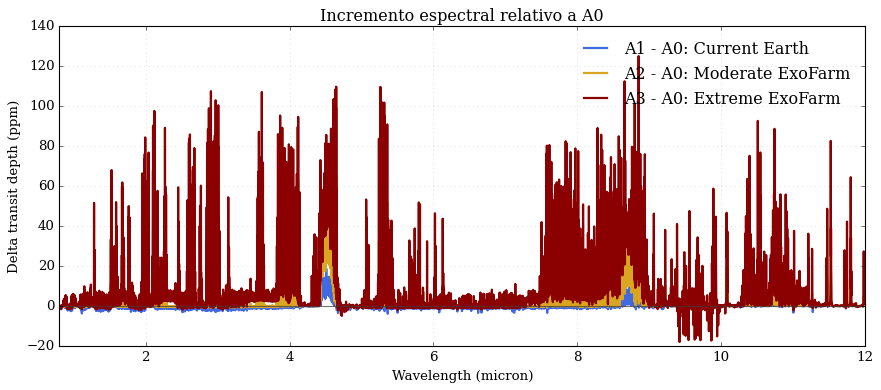

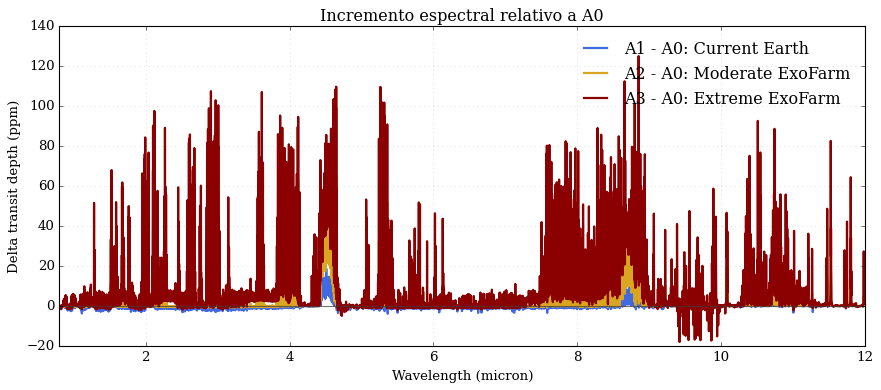

In [5]:
# Convert the model transit-depth differences to ppm for readability.  This is
# only a plotting unit conversion; the underlying spectra remain in (Rp/Rs)^2.
ppm = 1.0e6

fig_delta, ax = plt.subplots(figsize=(13, 5))
for key in SCENARIO_KEYS[1:]:
    delta_ppm = (spectra[key] - spectra["A0"]) * ppm
    ax.plot(
        wl,
        delta_ppm,
        color=SCENARIOS[key]["colour"],
        lw=2.0,
        label=f"{key} - A0: {SCENARIOS[key]['name']}",
    )

ax.axhline(0.0, color="0.25", lw=1.0, alpha=0.7)
ax.set_xlim(0.8, 12.0)
ax.set_xlabel("Wavelength (micron)")
ax.set_ylabel("Delta transit depth (ppm)")
ax.set_title("Incremento espectral relativo a A0")
ax.legend(frameon=False, loc="best")
ax.grid(alpha=0.2)
fig_delta

## 6. Lectura compacta

Esta tabla resume la amplitud máxima de las diferencias contra A0 en el rango que se usará para las observaciones sintéticas.

In [6]:
# A compact scalar diagnostic is helpful before generating many observations.
# It is not a detection metric; it only reports the largest absolute model
# separation from A0 over the plotted wavelength range.
summary_lines = [
    "| Escenario | max abs Delta(Ai-A0) en 0.8-12 micron (ppm) |",
    "| :-- | --: |",
]
for key in SCENARIO_KEYS[1:]:
    delta_ppm = np.abs((spectra[key][mask_plot] - spectra["A0"][mask_plot]) * ppm)
    summary_lines.append(f"| {key} - {SCENARIOS[key]['name']} | {delta_ppm.max():.2f} |")

display(Markdown("\n".join(summary_lines)))

| Escenario | max abs Delta(Ai-A0) en 0.8-12 micron (ppm) |
| :-- | --: |
| A1 - Current Earth | 23.96 |
| A2 - Moderate ExoFarm | 79.13 |
| A3 - Extreme ExoFarm | 124.97 |

## 7. Contribuciones espectrales relativas a A0

La figura principal mantiene la lógica del plot original: cada escenario se compara contra A0 y el panel inferior muestra la diferencia en ppm. Para evitar saturación, cada contraste vive en su propia columna: A1 - A0, A2 - A0 y A3 - A0. La escala de longitud de onda sigue siendo logarítmica, pero con ticks fijos más densos para leer mejor las bandas de NIRSpec y MIRI.

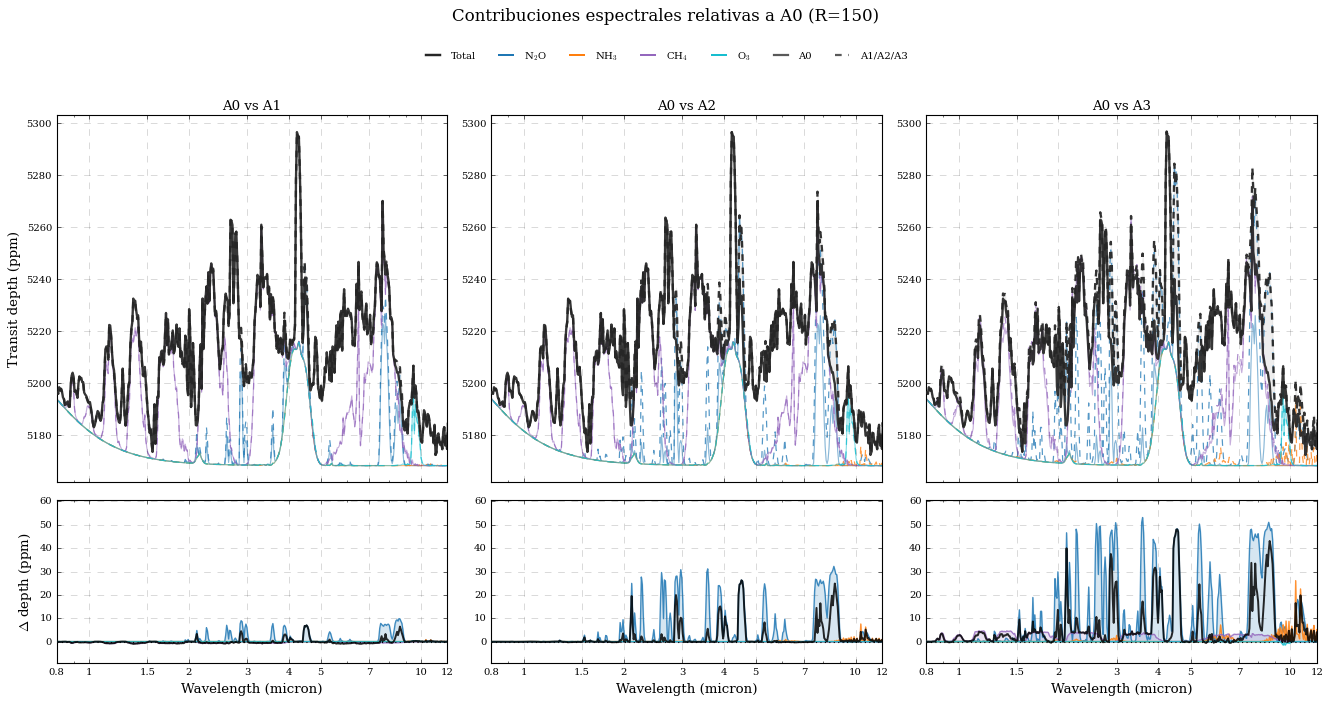

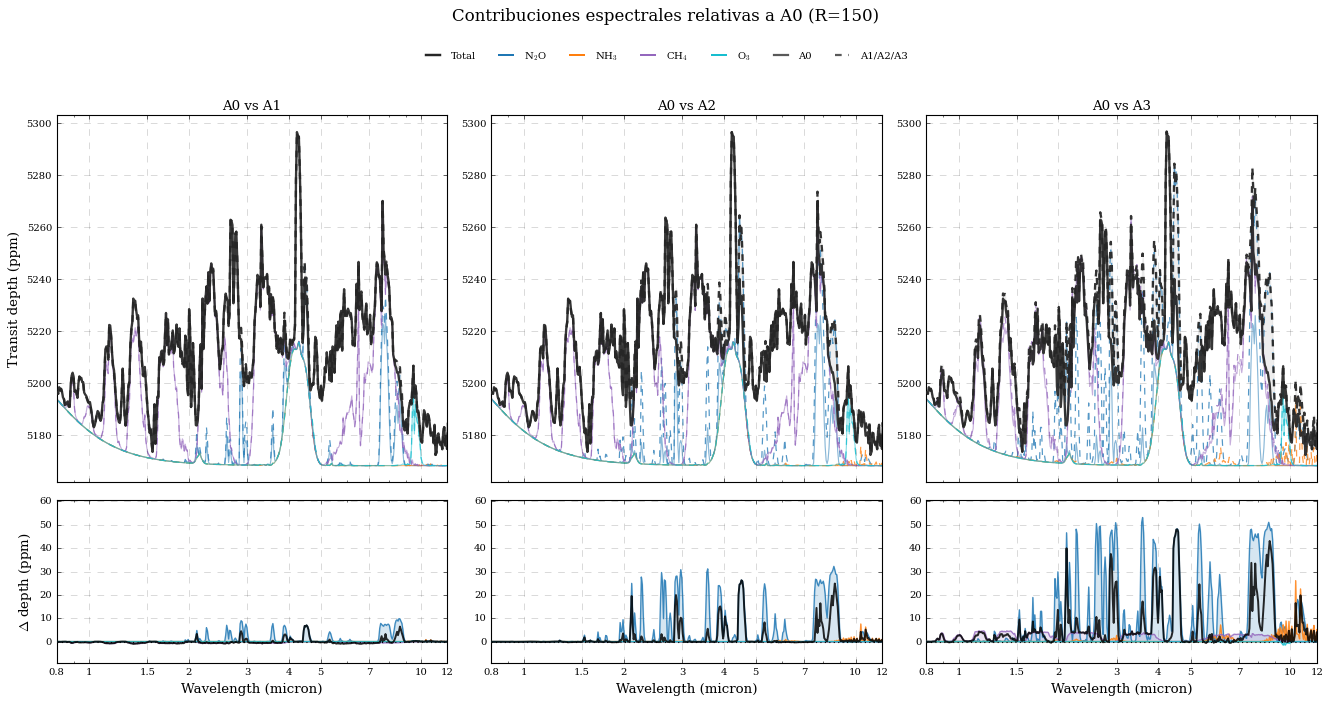

In [7]:
# Diagnostic contribution calculation.  This is more expensive than plotting
# only the total spectra, so it stays isolated.  We compute A0-A3 once and
# reuse the result for the baseline contrasts below.
spectral_contributions = compute_spectral_contributions(
    planet,
    star,
    models,
    atmospheres,
    opac,
    wl,
    scenario_keys=SCENARIO_KEYS,
    contribution_species=("N2O", "NH3", "CH4", "O3"),
)

fig_contribution_contrasts = plot_spectral_contribution_baseline_grid(
    wl,
    spectra,
    spectral_contributions,
    baseline_key="A0",
    comparison_keys=("A1", "A2", "A3"),
    R_plot=150,
    wl_min=0.8,
    wl_max=12.0,
)

fig_contribution_contrasts


## 8. Crecimiento de picos diagnósticos

Esta figura comprime los paneles de diferencia en una lectura cuantitativa: para cada escenario se mide el máximo aumento del espectro total respecto a A0 dentro de tres ventanas espectrales. Las etiquetas N$_2$O y NH$_3$ sólo indican qué molécula domina cada banda; la métrica es siempre `Total(Ai) - Total(A0)` en ppm.

Banda N$_2$O 1 | A1 | 4.44 ppm at 2.88 micron
Banda N$_2$O 1 | A2 | 19.91 ppm at 2.88 micron
Banda N$_2$O 1 | A3 | 37.52 ppm at 2.88 micron
Banda N$_2$O 2 | A1 | 4.19 ppm at 8.48 micron
Banda N$_2$O 2 | A2 | 19.62 ppm at 8.48 micron
Banda N$_2$O 2 | A3 | 37.20 ppm at 8.48 micron
Banda NH$_3$ | A1 | 0.53 ppm at 10.72 micron
Banda NH$_3$ | A2 | 5.17 ppm at 10.72 micron
Banda NH$_3$ | A3 | 19.80 ppm at 10.72 micron


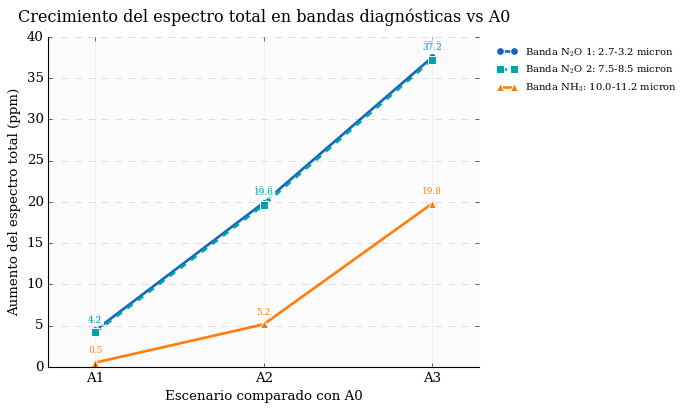

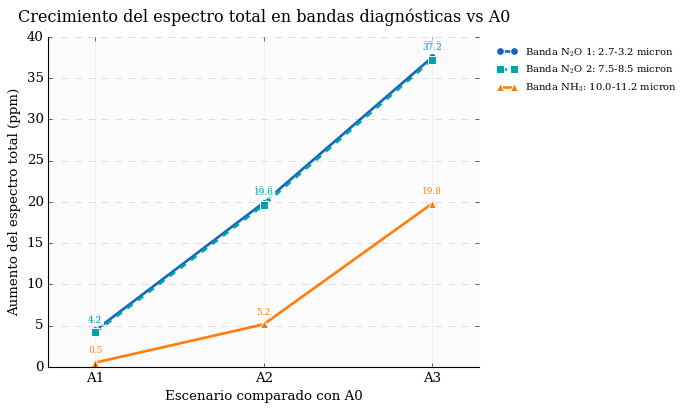

In [8]:
# Peak summary from rebinned total-spectrum differences.
# DEFAULT_PEAK_WINDOWS labels molecule-dominated bands, but the measured
# quantity is Total(Ai) - Total(A0), not an isolated molecular contribution.
fig_peak_growth, peak_growth_table = plot_peak_growth_relative_to_baseline(
    wl,
    spectra,
    baseline_key="A0",
    comparison_keys=("A1", "A2", "A3"),
    peak_windows=DEFAULT_PEAK_WINDOWS,
    R_plot=150,
)

for row in peak_growth_table:
    print(
        f"{row['feature']} | {row['scenario']} | "
        f"{row['magnitude_ppm']:.2f} ppm at {row['wavelength']:.2f} micron"
    )

fig_peak_growth



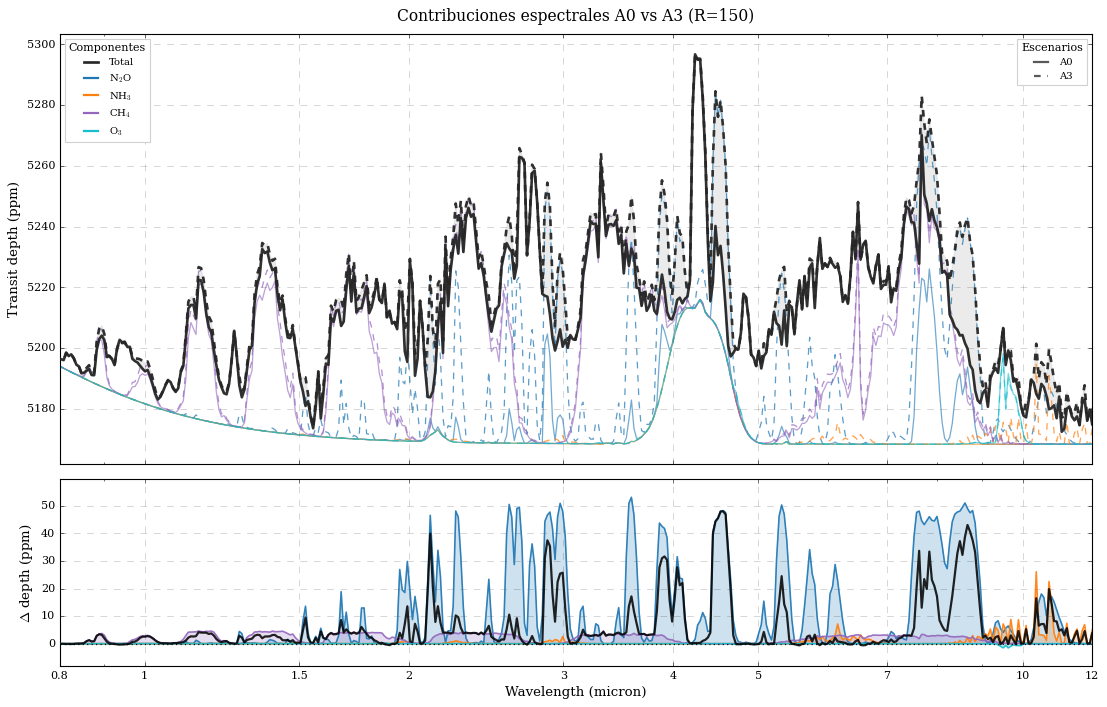

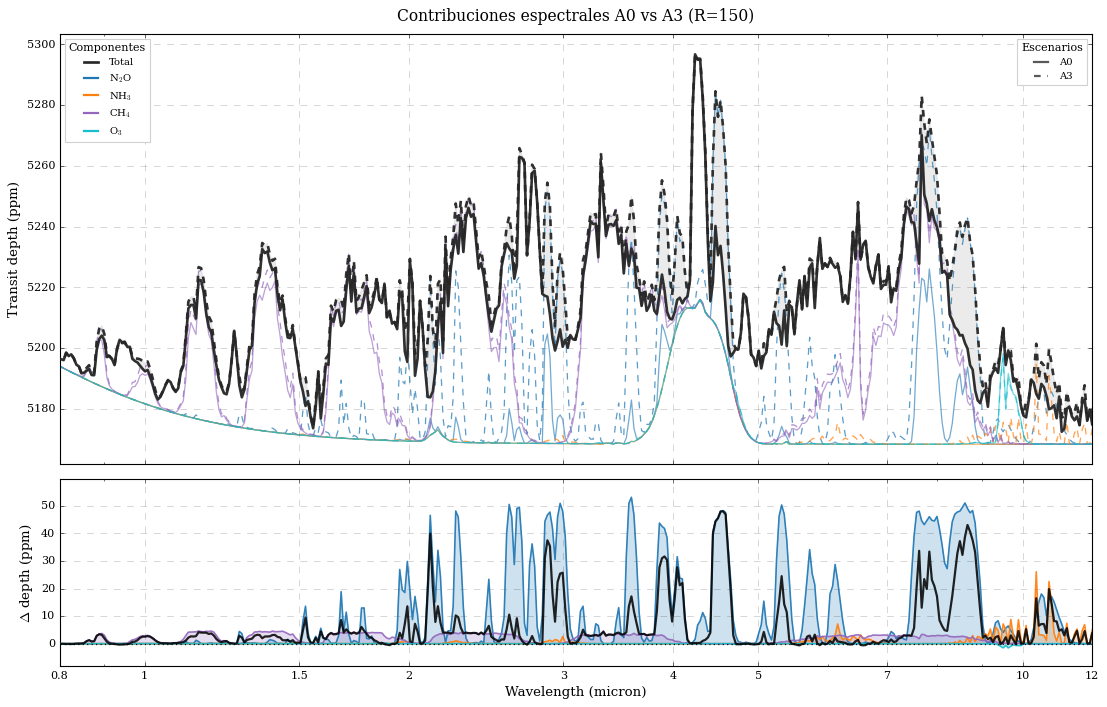

In [9]:
# Zoom opcional: el contraste A0 vs A3 en el formato original de dos paneles.
# Es útil para una figura de apoyo cuando queremos ver el caso extremo con más espacio.
fig_contributions_A0_A3 = plot_spectral_contribution_comparison(
    wl,
    spectra,
    spectral_contributions,
    baseline_key="A0",
    comparison_key="A3",
    R_plot=150,
    wl_min=0.8,
    wl_max=12.0,
)

fig_contributions_A0_A3


## 8. Plantillas observacionales PandExo

Antes de generar sintéticos para cada escenario, cargamos los productos base de PandExo de 1 tránsito para NIRSpec Prism y MIRI LRS. Estos archivos funcionan como plantilla instrumental para POSEIDON.

In [10]:
# Load the 1-transit PandExo templates.  These define the instrument sampling
# and uncertainties that POSEIDON scales when generating N-transit synthetic
# observations.
data_base, datasets_base = prepare_pandexo_base_data(wl)

print("Plantillas base cargadas:")
for dataset in datasets_base:
    print(" -", dataset)

Plantillas base cargadas:
 - TRAPPIST-1e_flat_NIRSpec_Prism_1_transits.dat
 - TRAPPIST-1e_flat_MIRI_LRS_1_transits.dat


## 10. Generación de observaciones sintéticas

La última celda genera la matriz completa de observaciones: A0, A1, A2 y A3 con 5+5, 10+10 y 20+20 tránsitos. Cada par significa la misma cantidad de observaciones en NIRSpec Prism y MIRI LRS.

Los archivos se guardan en `POSEIDON_output/TRAPPIST-1e/synthetic_data/base_1transit/`.

In [11]:
# This is the only cell that writes the final synthetic observation products.
# It generates A0-A3 for 5+5, 10+10, and 20+20 observations, where each pair is
# [NIRSpec Prism transits, MIRI LRS transits].
if RUN_SYNTHETIC_GENERATION:
    synthetic_runs = generate_synthetic_grid(
        planet,
        wl,
        spectra,
        data_base,
        scenario_keys=SCENARIO_KEYS,
        transit_counts=OBSERVATION_TRANSIT_COUNTS,
        gauss_scatter=GAUSS_SCATTER,
    )
else:
    synthetic_runs = {}
    print("RUN_SYNTHETIC_GENERATION=False; no se generaron archivos nuevos.")

# Print every generated filename so the notebook output becomes a run log.  This
# makes it easier to confirm that A1/A2 were included without browsing folders.
if synthetic_runs:
    print("\nObservaciones sintéticas generadas:")
    for (scenario_key, n_obs), run in synthetic_runs.items():
        print(f"\n{scenario_key} | NIRSpec={n_obs}, MIRI={n_obs}")
        for dataset in run["datasets"]:
            print(" -", dataset)

Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Observaciones sintéticas generadas:

A0 | NIRSpec=5, MIRI=5
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A0_PreAgri_N_trans_5.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A0_PreAgri_N_trans_5.dat

A0 | NIRSpec=10, MIRI=10
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A0_PreAgri_N_trans_10.dat

## 11. Visualización por escenario

Cada panel fija un escenario y superpone las observaciones de 5+5, 10+10 y 20+20 tránsitos. El espectro forward queda como línea continua; las barras de error cambian de color y forma según el número de observaciones.

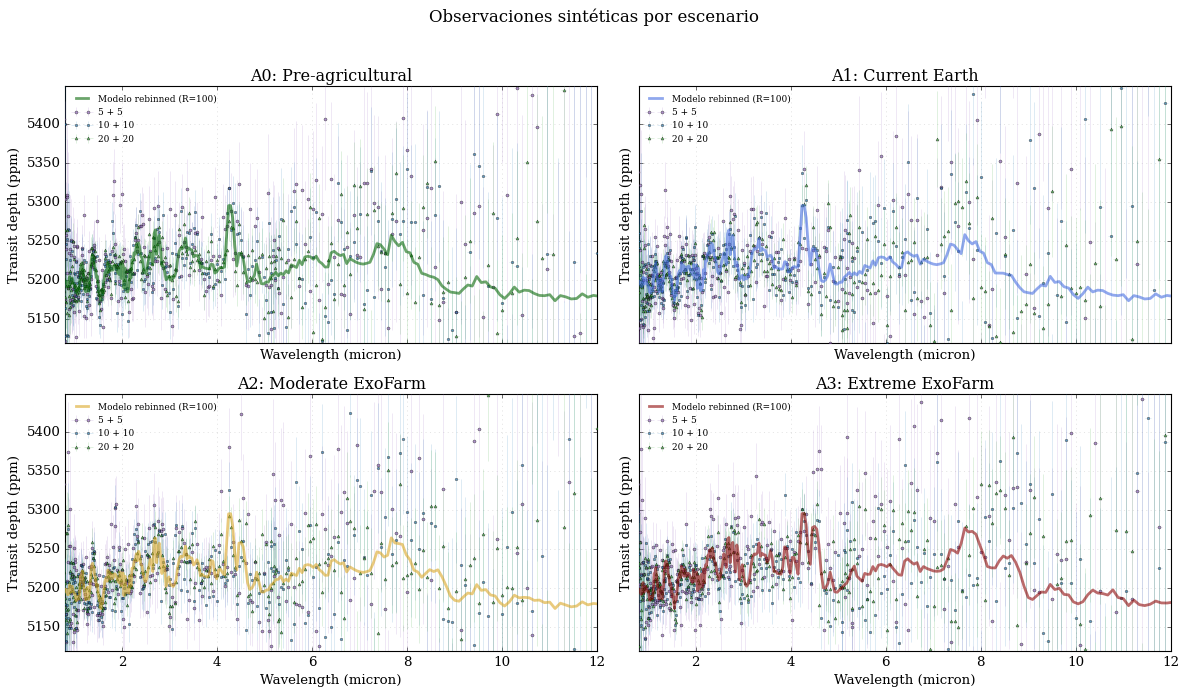

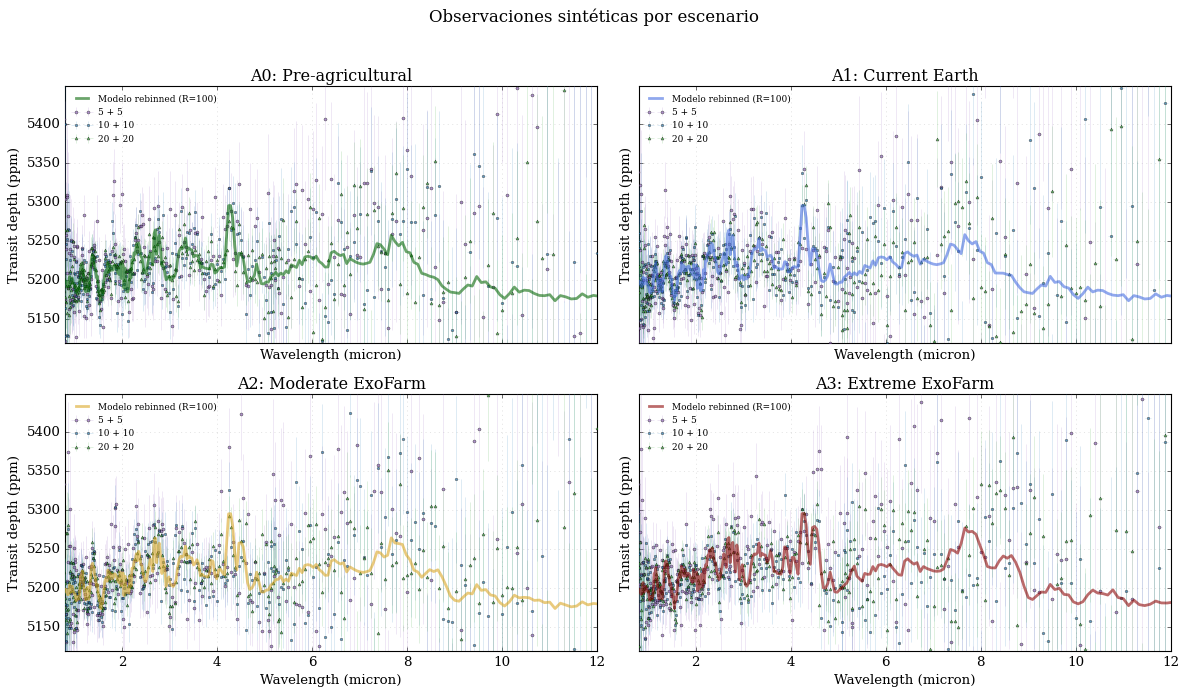

In [12]:
# Four panels, one for each atmospheric scenario.  The synthetic .dat files
# were generated with R_TO_BIN=[100, 100], and the central model curve is
# also rebinned to R=100 here so the comparison stays readable.
fig_by_scenario = plot_observations_by_scenario(
    wl,
    spectra,
    scenario_keys=SCENARIO_KEYS,
    transit_counts=OBSERVATION_TRANSIT_COUNTS,
    R_model_bin=100,
    wl_min=0.8,
    wl_max=12.0,
)

fig_by_scenario

## 12. Visualización por nivel de ruido

Ahora cada panel fija el presupuesto observacional: 5+5, 10+10 o 20+20. Dentro de cada panel se comparan A0, A1, A2 y A3 con colores y marcadores distintos.

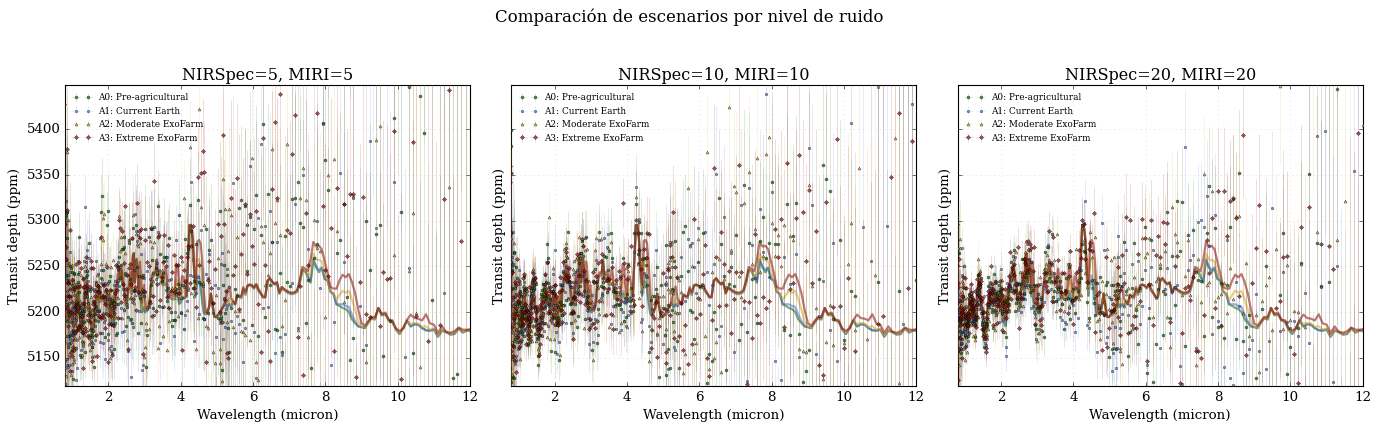

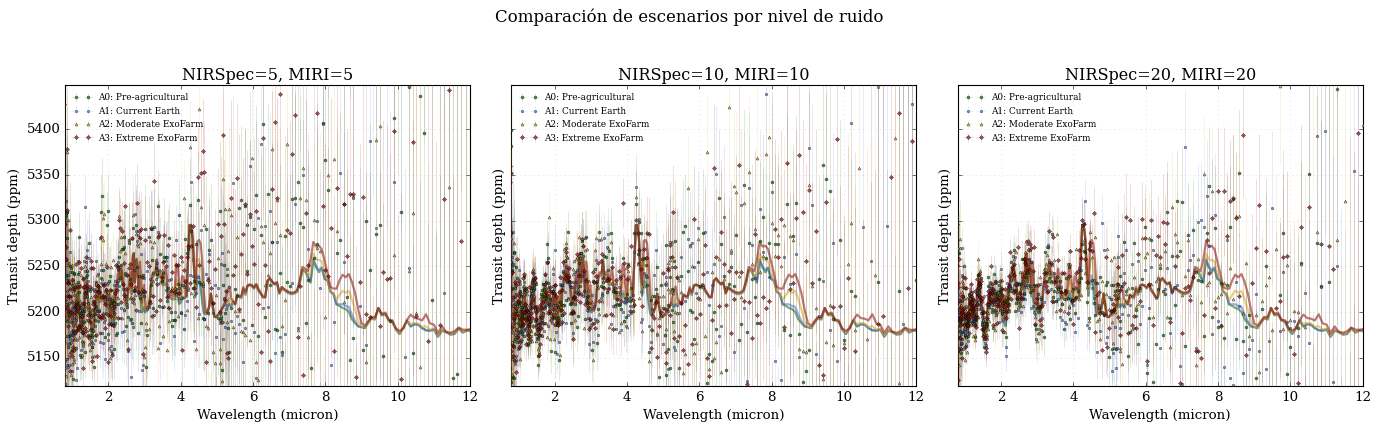

In [13]:
# Three panels, one per noise level / observation count.  The model curves are
# rebinned to R=100 and plotted with low alpha; the points carry the scenario
# colours while the error bars stay intentionally soft.
fig_by_noise = plot_observations_by_noise_level(
    wl,
    spectra,
    scenario_keys=SCENARIO_KEYS,
    transit_counts=OBSERVATION_TRANSIT_COUNTS,
    R_model_bin=100,
    wl_min=0.8,
    wl_max=12.0,
)

fig_by_noise